In [1]:
pip install python-chess

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
import chess
import chess.pgn
import random
import json

In [2]:
board = chess.Board()
print(board)

r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R


In [3]:
for move in board.legal_moves:
    print(move)

g1h3
g1f3
b1c3
b1a3
h2h3
g2g3
f2f3
e2e3
d2d3
c2c3
b2b3
a2a3
h2h4
g2g4
f2f4
e2e4
d2d4
c2c4
b2b4
a2a4


In [4]:
board.push(chess.Move.from_uci("e2e4"))

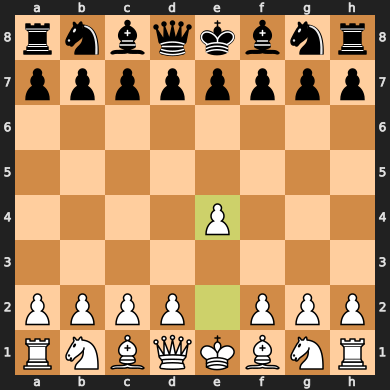

In [5]:
board

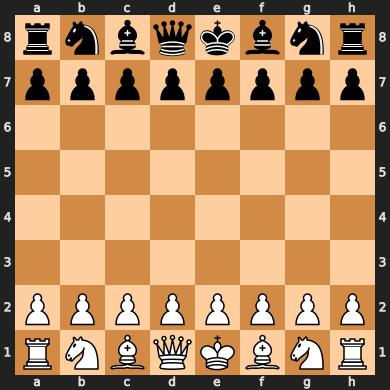

In [6]:
board.reset()
board

In [9]:
final = []

for i in range(1):
    data = []
    board.reset()
    data.append(board.fen())
    while not board.is_game_over():
        move = random.choice(list(board.legal_moves))
        board.push(move)
        data.append(board.fen())
    outcome=0
    if board.outcome().result() == "1-0":
        outcome = 1
    elif board.outcome().result() == "0-1":
        outcome = -1
    
    for j in range(len(data)):
        data[j] = {"fen": data[j], "result": outcome}

    final.append(data)

In [10]:
with open('data.json', "w") as file:
    json.dump(final, file)
    

In [47]:
def encode(fen):
    
    board_array = np.zeros((8, 8, 12), dtype=np.uint8)
    fen = fen.split("/")
    for rank in range(0, 8):
        col = 0
        r = ""
        if fen[rank].find(" ") == -1:
            r = fen[rank]    
        else:
            r = fen[rank][:fen[rank].find(" ")]

        for char in r:
            
            if char.isdigit():
                col += int(char)
            else:
                board_array[7-rank][col][key[char]] = 1
                col += 1    
    return board_array


In [48]:
def extract_fens_grouped(pgn_path):
    all_fens = []
    with open(pgn_path, "r") as pgn_file:
        while True:
            game = chess.pgn.read_game(pgn_file)
            if game is None:
                break
            board = game.board()
            game_fens = []
            for move in game.mainline_moves():
                board.push(move)
                game_fens.append(board.fen())
            all_fens.append(game_fens)
    return all_fens

In [49]:
my_games = extract_fens_grouped("masaurus101-white.pgn")

In [50]:
import numpy as np

X = []
y=[]
key = {
  'P': 0, 'N': 1, 'B': 2, 'R': 3, 'Q': 4, 'K': 5,
  'p': 6, 'n': 7, 'b': 8, 'r': 9, 'q': 10, 'k': 11
}

with open("tal.pgn") as pgn_file:
    while True:
        game = chess.pgn.read_game(pgn_file)
        if game is None:
            break

        board = game.board()
        result = game.headers["Result"]
        if result == "1-0":
            score = 1
        elif result == "0-1":
            score = -1
        else:
            score = 0
            
        for move in game.mainline_moves():
            X.append(encode(board.fen()))
            y.append(score)
            board.push(move)

In [51]:

import torch
import torch.nn as nn
import torch.nn.functional as F

In [52]:
class ChessNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(12*8*8, 128)
        self.fc2 = nn.Linear(128, 1)
        
    def forward(self,x):
        x = self.flatten(x) #board (12,8,8) to (1, 768) vector
        x = F.relu(self.fc1(x)) #pass through first layer
        x = torch.tanh(self.fc2(x)) #pass through second layer and makes output between -1, 1
        return x.squeeze(1) # (batch_size, 1) to (batch_size)

model = ChessNN()
device = torch.device("cuda")
model.to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [53]:

X_np = np.stack(X)
y_np = np.array(y)

X_np = X_np.transpose(0,3,1,2)

X_tensor = torch.from_numpy(X_np).float()
y_tensor = torch.from_numpy(y_np).float()

In [54]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader


In [55]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)


In [56]:
epochs = 25


for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
    
        optimizer.zero_grad()
        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f}")

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for val_X, val_y in val_loader:
            val_X = val_X.to(device)
            val_y = val_y.to(device)
    
            val_preds = model(val_X)
            val_loss += loss_fn(val_preds, val_y).item()
        avg_val_loss = val_loss / len(val_loader)
        print(f"           | Val Loss:   {avg_val_loss:.4f}")


Epoch 1 | Train Loss: 0.3859
           | Val Loss:   0.2854
Epoch 2 | Train Loss: 0.2359
           | Val Loss:   0.2298
Epoch 3 | Train Loss: 0.1971
           | Val Loss:   0.2103
Epoch 4 | Train Loss: 0.1804
           | Val Loss:   0.1976
Epoch 5 | Train Loss: 0.1708
           | Val Loss:   0.1909
Epoch 6 | Train Loss: 0.1633
           | Val Loss:   0.1864
Epoch 7 | Train Loss: 0.1584
           | Val Loss:   0.1850
Epoch 8 | Train Loss: 0.1547
           | Val Loss:   0.1835
Epoch 9 | Train Loss: 0.1513
           | Val Loss:   0.1838
Epoch 10 | Train Loss: 0.1482
           | Val Loss:   0.1806
Epoch 11 | Train Loss: 0.1460
           | Val Loss:   0.1794
Epoch 12 | Train Loss: 0.1434
           | Val Loss:   0.1782
Epoch 13 | Train Loss: 0.1416
           | Val Loss:   0.1794
Epoch 14 | Train Loss: 0.1400
           | Val Loss:   0.1758
Epoch 15 | Train Loss: 0.1380
           | Val Loss:   0.1762
Epoch 16 | Train Loss: 0.1370
           | Val Loss:   0.1751
Epoch 17 | Train 

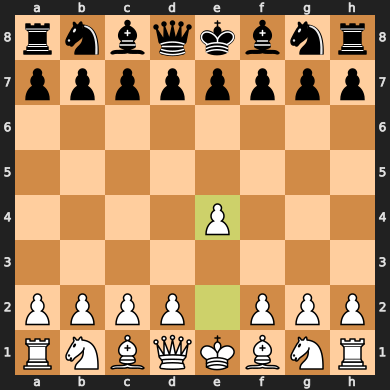

In [57]:
board = chess.Board()

best_move = None
best_value = -float("inf")

for move in board.legal_moves:
    temp = board.copy()
    temp.push(move)

    encoded = encode(temp.fen())
    input_tensor = torch.tensor(encoded, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        value = model(input_tensor).item()
        if value > best_value:
            best_value = value
            best_move = move
board.push(best_move)
board

In [58]:
def make_move(board):
    best_value = -float("inf")
    for move in board.legal_moves:
        temp = board.copy()
        temp.push(move)
    
        encoded = encode(temp.fen())
        input_tensor = torch.tensor(encoded, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
        input_tensor = input_tensor.to(device)
    
        with torch.no_grad():
            value = model(input_tensor).item()
            if value > best_value:
                best_value = value
                best_move = move
    return best_move

In [62]:
board.reset()
turn = 0
while not board.is_game_over():
    if turn == 0:
        move = random.choice(list(board.legal_moves))
        board.push(move)
        turn = 1
    else:
        make_move(board)
        turn = 0

with open("random.pgn", "w") as f:
    print(game, file=f)

In [61]:
moves = list(board.move_stack)
print(moves)


[Move.from_uci('g2g4'), Move.from_uci('g8f6'), Move.from_uci('b2b3'), Move.from_uci('f6g4'), Move.from_uci('d2d3'), Move.from_uci('c7c5'), Move.from_uci('f1h3'), Move.from_uci('g4h6'), Move.from_uci('c1d2'), Move.from_uci('b7b6'), Move.from_uci('d1c1'), Move.from_uci('b6b5'), Move.from_uci('b1c3'), Move.from_uci('d7d6'), Move.from_uci('c3b1'), Move.from_uci('g7g5'), Move.from_uci('h3d7'), Move.from_uci('c8d7'), Move.from_uci('b1c3'), Move.from_uci('h8g8'), Move.from_uci('e2e4'), Move.from_uci('f7f6'), Move.from_uci('c3d1'), Move.from_uci('d6d5'), Move.from_uci('b3b4'), Move.from_uci('d7f5'), Move.from_uci('c1b2'), Move.from_uci('f5c8'), Move.from_uci('d1c3'), Move.from_uci('c8b7'), Move.from_uci('b2b1'), Move.from_uci('b8a6'), Move.from_uci('g1h3'), Move.from_uci('d8b8'), Move.from_uci('e1g1'), Move.from_uci('b7c6'), Move.from_uci('e4e5'), Move.from_uci('c5c4'), Move.from_uci('f1d1'), Move.from_uci('b8d8'), Move.from_uci('d3c4'), Move.from_uci('e8f7'), Move.from_uci('g1f1'), Move.from_

In [65]:
board = chess.Board()
game = chess.pgn.Game()
node = game

for move in moves:
    board.push(move)
    node = node.add_main_variation(move)

# Print PGN to console
print(game)


[Event "?"]
[Site "?"]
[Date "????.??.??"]
[Round "?"]
[White "?"]
[Black "?"]
[Result "*"]

1. g4 Nf6 2. b3 Nxg4 3. d3 c5 4. Bh3 Nh6 5. Bd2 b6 6. Qc1 b5 7. Nc3 d6 8. Nb1 g5 9. Bd7+ Bxd7 10. Nc3 Rg8 11. e4 f6 12. Nd1 d5 13. b4 Bf5 14. Qb2 Bc8 15. Nc3 Bb7 16. Qb1 Na6 17. Nh3 Qb8 18. O-O Bc6 19. e5 c4 20. Rd1 Qd8 21. dxc4 Kf7 22. Kf1 Ke6 23. exf6 Bg7 24. cxb5 Nf5 25. a4 Be8 26. Ra2 Qb8 27. Ne2 Nd6 28. Bxg5 Qb6 29. a5 Kd7 30. Rd3 Nc4 31. f7 Rh8 32. Bh4 Kd8 33. Rd4 Qe6 34. Qe1 Na3 35. fxe8=Q+ Kxe8 36. Rd2 Qg8 37. Ra1 Kf8 38. Bg3 Nc7 39. Bxc7 Nc4 40. Rd4 h5 41. Ra4 Ke8 42. Ng5 Bf8 43. f4 a6 44. Ne4 Qf7 45. Nd2 Ne5 46. Kg2 Qh7 47. Ng1 Ng6 48. Qa1 e5 49. Kf3 h4 50. Ra3 exd4 51. Nh3 Kd7 52. Bd6 Re8 53. Be5 Rb8 54. Qf1 Qf7 55. Kg2 Nxe5 56. Qg1 d3 57. fxe5 axb5 58. Qc5 d4 59. Nf2 Bxc5 60. Ng4 Kc6 61. Ra4 Rbc8 62. Kh1 Qg7 63. Nf1 Qd7 64. Ng3 Rh5 65. c3 Qa7 66. Nf2 Kd7 67. c4 Qb6 68. Nf5 Rh7 69. axb6 Kd8 70. bxc5 Rxc5 71. e6 Rxc4 72. Ng4 Rd7 73. e7+ Kc8 74. Ra1 Rd6 75. Ra8+ Kd7 76. Ra7+ Ke8 77. Ng

In [ ]:
[Event "?"]
[Site "?"]
[Date "????.??.??"]
[Round "?"]
[White "random moves"]
[Black "first gen tal bot"]
[Result "*"]

1. g4 Nf6 2. b3 Nxg4 3. d3 c5 4. Bh3 Nh6 5. Bd2 b6 6. Qc1 b5 7. Nc3 d6 8. Nb1 g5 9. Bd7+ Bxd7 10. Nc3 Rg8 11. e4 f6 12. Nd1 d5 13. b4 Bf5 14. Qb2 Bc8 15. Nc3 Bb7 16. Qb1 Na6 17. Nh3 Qb8 18. O-O Bc6 19. e5 c4 20. Rd1 Qd8 21. dxc4 Kf7 22. Kf1 Ke6 23. exf6 Bg7 24. cxb5 Nf5 25. a4 Be8 26. Ra2 Qb8 27. Ne2 Nd6 28. Bxg5 Qb6 29. a5 Kd7 30. Rd3 Nc4 31. f7 Rh8 32. Bh4 Kd8 33. Rd4 Qe6 34. Qe1 Na3 35. fxe8=Q+ Kxe8 36. Rd2 Qg8 37. Ra1 Kf8 38. Bg3 Nc7 39. Bxc7 Nc4 40. Rd4 h5 41. Ra4 Ke8 42. Ng5 Bf8 43. f4 a6 44. Ne4 Qf7 45. Nd2 Ne5 46. Kg2 Qh7 47. Ng1 Ng6 48. Qa1 e5 49. Kf3 h4 50. Ra3 exd4 51. Nh3 Kd7 52. Bd6 Re8 53. Be5 Rb8 54. Qf1 Qf7 55. Kg2 Nxe5 56. Qg1 d3 57. fxe5 axb5 58. Qc5 d4 59. Nf2 Bxc5 60. Ng4 Kc6 61. Ra4 Rbc8 62. Kh1 Qg7 63. Nf1 Qd7 64. Ng3 Rh5 65. c3 Qa7 66. Nf2 Kd7 67. c4 Qb6 68. Nf5 Rh7 69. axb6 Kd8 70. bxc5 Rxc5 71. e6 Rxc4 72. Ng4 Rd7 73. e7+ Kc8 74. Ra1 Rd6 75. Ra8+ Kd7 76. Ra7+ Ke8 77. Nge3 Rf6 78. h3 Rc2 79. Nxd4 Rf4 80. Ne6 Rc3 81. Nc5 Rxc5 82. Ng4 Rb4 83. Ra5 Rb2 84. Ne5 Rc6 85. Nc4 Rd6 86. Nxb2 Rf6 87. Nd1 Kf7 88. Ra8 Rd6 89. Rf8+ Kxe7 90. Rd8 Rd7 91. Kg1 b4 92. Ra8 Rd8 93. Ra5 Rd7 94. Rf5 Kd6 95. Ra5 Rb7 96. Ra7 b3 97. Kh1 Re7 98. b7 Rg7 99. Nb2 Kc6 100. Nd1 Re7 101. Ra2 bxa2 102. Kg2 Re3 103. b8=Q a1=B 104. Qd6+ Kxd6 105. Kf1 Bd4 106. Nc3 d2 107. Na2 Kc7 108. Nc3 Ba7 109. Kg1 Bb6 110. Kg2 Rxc3 111. Kh1 Rf3 112. Kh2 Kc6 113. Kg2 Kc5 114. Kh2 Kd4 115. Kh1 Ke5 116. Kg2 Bf2 117. Kxf3 d1=B+ 118. Kg2 Kf4 119. Kxf2 Bb3 120. Ke1 Bg8 121. Kd2 Bc4 122. Ke1 Bb3 123. Kf2 Bc4 124. Kg2 Bg8 125. Kg1 Ke5 126. Kf2 Ke6 127. Kg2 Kf7 128. Kh2 Ke6 129. Kg2 Kd5 130. Kg1 Kc4 131. Kf2 Kd4 132. Kg1 Kd5 133. Kg2 Bh7 134. Kf3 Bg6 135. Ke2 Kd4 136. Kd2 Bd3 137. Kc1 Kc4 138. Kd2 Be4 139. Ke1 Bg6 140. Kd1 Kc3 141. Kc1 Kb4 142. Kb2 Kc4 143. Ka1 Kd4 144. Kb2 Bf7 145. Ka3 Kd5 146. Kb4 Kd6 147. Kc3 Kc7 148. Kd2 Bg8 149. Kc1 Kb6 150. Kb2 Kb7 151. Kc3 Kc6 152. Kd3 Bh7+ 153. Kd4 Bf5 154. Ke3 Kb5 155. Ke2 Kc5 156. Kd2 Kd4 157. Kc1 Be4 158. Kb2 Bh1 159. Kb3 Bf3 160. Ka3 Kd3 161. Kb2 Kc4 162. Ka3 Bg4 163. Ka4 Kd3 164. Kb3 Be6+ 165. Ka3 Kc2 166. Kb4 Bg4 167. Kc4 Be6+ 168. Kb4 Bg4 169. Ka5 Kd2 170. Ka6 Bc8+ 171. Ka5 Kd1 172. Ka4 Bg4 173. Kb5 Bxh3 174. Kb6 Be6 175. Kc5 Bh3 176. Kd5 Be6+ 177. Kc5 Bf7 178. Kb4 Be8 179. Kc5 Ke1 180. Kd4 Bd7 181. Kc4 Kf1 182. Kc5 Bf5 183. Kc6 Ke1 184. Kc7 Bd3 185. Kb8 Kd1 186. Kb7 Bc4 187. Kc8 Kc2 188. Kb7 Bb3 189. Ka7 Kd1 190. Ka6 Ba4 191. Ka5 Kd2 192. Ka6 Ke2 193. Kb6 Bb3 194. Kb5 Bc2 195. Ka6 Kf2 196. Kb6 Bd1 197. Kb7 Ba4 198. Kc8 Bb3 199. Kc7 Bg8 200. Kb8 Bc4 201. Kb7 Kf3 202. Ka8 Be2 203. Ka7 Bb5 204. Ka8 Kg3 205. Kb7 Bd3 206. Kb6 Kg4 207. Kb7 Kf3 208. Ka8 Bf1 209. Kb8 Ke3 210. Ka8 Kf2 211. Kb8 Kg2 212. Kc8 Kh3 213. Kd8 Be2 214. Kc7 Kg3 215. Kd7 Bh5 216. Kc6 Bf3+ 217. Kc5 Kh3 218. Kb4 Bh5 219. Kc5 Bf7 220. Kd6 Kg4 221. Kc7 Kh5 222. Kc8 Bb3 223. Kb8 h3 224. Ka7 Bg8 225. Ka8 Bh7 226. Kb8 Be4 227. Ka7 Bd3 228. Ka8 Be4+ 229. Ka7 Bb7 230. Kb6 Bc8 231. Kc7 Bf5 232. Kb8 Kg6 233. Kc7 Bc8 234. Kb6 Bd7 235. Ka5 Bg4 236. Ka4 Bh5 237. Ka5 Kf5 238. Kb4 Bg4 239. Ka4 Bd1+ 240. Kb5 Be2+ 241. Kb6 Bd3 242. Kc7 Bc4 243. Kd7 Kf6 244. Kd6 Be6 245. Kc6 Bd5+ 246. Kd7 Ba8 247. Kd6 Kg6 248. Kc7 Kg5 249. Kd7 Kg6 250. Ke8 Bh1 251. Ke7 Bg2 252. Kd6 Bd5 253. Ke7 Kg7 254. Kd6 Bc4 255. Kd7 Kh6 256. Ke8 Ba6 257. Kf8 Kg6 258. Ke7 Kh7 259. Kd6 h2 260. Kc7 Kg7 261. Kb8 Kf8 262. Ka8 h1=B+ *